In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
fund_master = pd.read_csv("data/raw/01_fund_master.csv")
nav = pd.read_csv("data/raw/02_nav_history.csv")
performance = pd.read_csv("data/raw/07_scheme_performance.csv")
benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/01_fund_master.csv'

In [3]:
import os

print(os.getcwd())

/Users/krithikmenon/Desktop/blue stock mutual fund /notebooks/reports


In [4]:
import pandas as pd

fund_master = pd.read_csv("../../data/raw/01_fund_master.csv")
nav = pd.read_csv("../../data/raw/02_nav_history.csv")
performance = pd.read_csv("../../data/raw/07_scheme_performance.csv")
benchmark = pd.read_csv("../../data/raw/10_benchmark_indices.csv")

In [5]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav.shape)
print("Performance:", performance.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
Performance: (40, 19)
Benchmark: (8050, 3)


In [6]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [7]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [8]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [9]:
nav = nav.sort_values(["amfi_code", "date"])

In [10]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [11]:
nav[["amfi_code", "date", "nav", "daily_return"]].head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


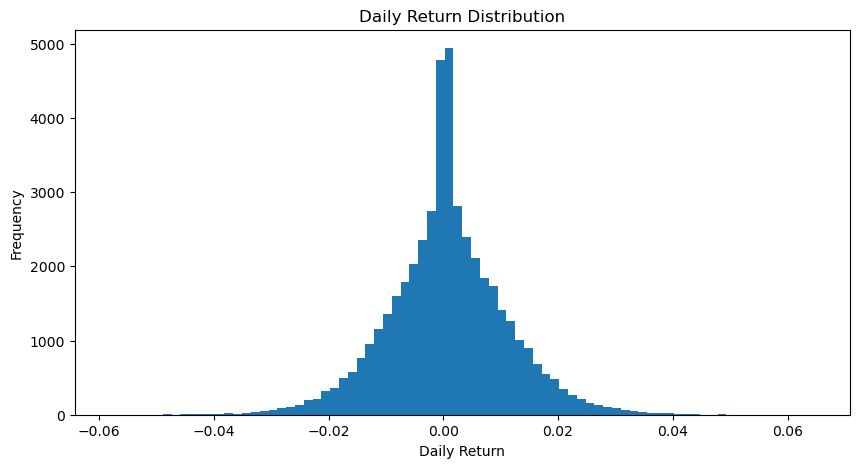

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(nav["daily_return"].dropna(), bins=80)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [13]:
nav.to_csv("../../data/processed/nav_daily_returns.csv", index=False)

In [14]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')


In [15]:
nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


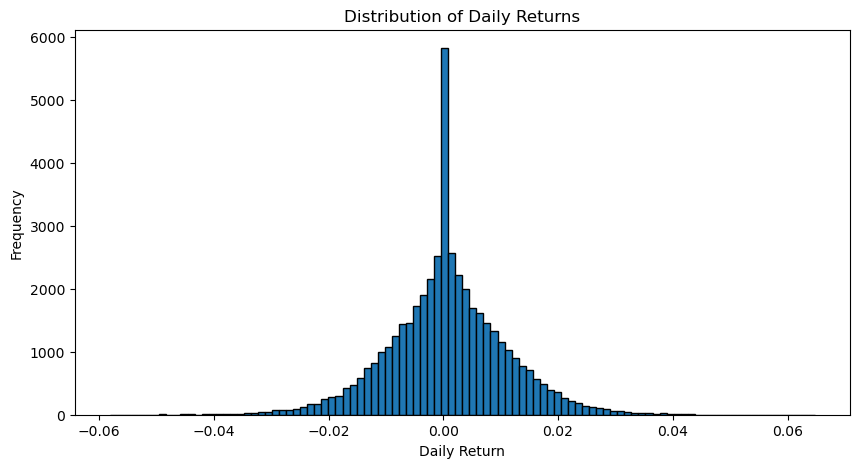

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(nav["daily_return"].dropna(), bins=100, edgecolor="black")

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [17]:
from datetime import timedelta

def calculate_cagr(nav_df, years):
    results = []

    latest_date = nav_df["date"].max()

    for code, df in nav_df.groupby("amfi_code"):

        df = df.sort_values("date")

        end_nav = df.iloc[-1]["nav"]

        start_date = latest_date - pd.DateOffset(years=years)

        start_data = df[df["date"] >= start_date]

        if len(start_data) == 0:
            continue

        start_nav = start_data.iloc[0]["nav"]

        cagr = (end_nav / start_nav) ** (1 / years) - 1

        results.append([code, cagr])

    return pd.DataFrame(results, columns=["amfi_code", f"{years}Y_CAGR"])

In [18]:
cagr_1 = calculate_cagr(nav, 1)
cagr_3 = calculate_cagr(nav, 3)
cagr_5 = calculate_cagr(nav, 5)

In [19]:
cagr = cagr_1.merge(cagr_3, on="amfi_code", how="outer")
cagr = cagr.merge(cagr_5, on="amfi_code", how="outer")

cagr.head()

,amfi_code,1Y_CAGR,3Y_CAGR,5Y_CAGR
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [20]:
cagr.to_csv("../../data/processed/cagr_report.csv", index=False)

In [21]:
cagr.to_csv("../../data/processed/cagr_report.csv", index=False)

In [22]:
rf = 0.065

In [23]:
sharpe = []

for code, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    mean_return = returns.mean()

    std_return = returns.std()

    sharpe_ratio = ((mean_return * 252) - rf) / (std_return * np.sqrt(252))

    sharpe.append([code, sharpe_ratio])

sharpe_df = pd.DataFrame(
    sharpe,
    columns=["amfi_code", "Sharpe_Ratio"]
)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [24]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [25]:
sharpe_df.to_csv(
    "../../data/processed/sharpe_ratio.csv",
    index=False
)

In [26]:
downside = returns[returns < 0]

In [27]:
rf = 0.065

sortino = []

for code, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    downside = returns[returns < 0]

    annual_return = returns.mean() * 252

    downside_std = downside.std() * np.sqrt(252)

    if downside_std == 0 or np.isnan(downside_std):
        ratio = np.nan
    else:
        ratio = (annual_return - rf) / downside_std

    sortino.append([code, ratio])

sortino_df = pd.DataFrame(
    sortino,
    columns=["amfi_code", "Sortino_Ratio"]
)

sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,Sortino_Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [28]:
sortino_df.to_csv(
    "../../data/processed/sortino_ratio.csv",
    index=False
)

In [29]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [30]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [31]:
benchmark["date"] = pd.to_datetime(benchmark["date"])
benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = benchmark["nav"].pct_change()

KeyError: 'nav'

In [32]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [33]:
benchmark["index_name"].unique()

array(['NIFTY50', 'CRISIL_LIQUID', 'NIFTY_MIDCAP150', 'CRISIL_GILT',
       'NIFTY100', 'NIFTY500', 'BSE_SMALLCAP'], dtype=object)

In [34]:
nifty100 = benchmark[benchmark["index_name"]=="Nifty 100"].copy()

In [35]:
nifty100["date"] = pd.to_datetime(nifty100["date"])
nifty100 = nifty100.sort_values("date")

In [36]:
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

In [37]:
nifty100.head()

,date,index_name,close_value,benchmark_return


In [38]:
nifty100["benchmark_return"]

Series([], Name: benchmark_return, dtype: float64)

In [39]:
benchmark["benchmark_return"]

KeyError: 'benchmark_return'

In [40]:
benchmark["index_name"].unique()

array(['NIFTY50', 'CRISIL_LIQUID', 'NIFTY_MIDCAP150', 'CRISIL_GILT',
       'NIFTY100', 'NIFTY500', 'BSE_SMALLCAP'], dtype=object)

In [41]:
nifty100 = benchmark[benchmark["index_name"]=="Nifty 100"].copy()

In [42]:
nifty100["date"] = pd.to_datetime(nifty100["date"])

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()


In [43]:
nifty100.head()

,date,index_name,close_value,benchmark_return


In [44]:
benchmark["index_name"].unique()

array(['NIFTY50', 'CRISIL_LIQUID', 'NIFTY_MIDCAP150', 'CRISIL_GILT',
       'NIFTY100', 'NIFTY500', 'BSE_SMALLCAP'], dtype=object)

In [45]:
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

In [46]:
nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [47]:
nifty100["date"] = pd.to_datetime(nifty100["date"])
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

In [48]:
nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [49]:
print(len(nifty100))

1150


In [50]:
from scipy.stats import linregress

alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund][["date","daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100[["date","benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    beta, alpha, r, p, stderr = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": fund,
        "Alpha": alpha * 252,
        "Beta": beta
    })

alpha_beta = pd.DataFrame(alpha_beta)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [51]:
alpha_beta.to_csv("../../data/processed/alpha_beta.csv", index=False)

In [52]:
drawdowns = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"]==fund].copy()

    df["running_max"] = df["nav"].cummax()

    df["drawdown"] = df["nav"]/df["running_max"] - 1

    drawdowns.append({
        "amfi_code":fund,
        "Max_Drawdown":df["drawdown"].min()
    })

drawdowns = pd.DataFrame(drawdowns)

drawdowns.head()


,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [53]:
scorecard = cagr.merge(sharpe,on="amfi_code")
scorecard = scorecard.merge(alpha_beta,on="amfi_code")
scorecard = scorecard.merge(drawdowns,on="amfi_code")

TypeError: Can only merge Series or DataFrame objects, a <class 'list'> was passed

In [54]:
print(type(cagr))
print(type(sharpe))
print(type(alpha_beta))
print(type(drawdowns))

<class 'pandas.core.frame.DataFrame'>
<class 'list'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [55]:
print(cagr.columns)
print(sharpe.columns)
print(alpha_beta.columns)
print(drawdowns.columns)

Index(['amfi_code', '1Y_CAGR', '3Y_CAGR', '5Y_CAGR'], dtype='object')


AttributeError: 'list' object has no attribute 'columns'

In [56]:
sharpe = pd.DataFrame(sharpe)

In [57]:
type(sharpe)

pandas.core.frame.DataFrame

In [58]:
sharpe = pd.DataFrame(sharpe)


In [59]:
sharpe.head()

,0,1
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [60]:
sharpe.columns = ["amfi_code", "Sharpe"]

sharpe.head()

,amfi_code,Sharpe
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [61]:
scorecard = cagr.merge(sharpe, on="amfi_code")
scorecard = scorecard.merge(alpha_beta, on="amfi_code")
scorecard = scorecard.merge(drawdowns, on="amfi_code")

scorecard.head()


,amfi_code,1Y_CAGR,3Y_CAGR,5Y_CAGR,Sharpe,Alpha,Beta,Max_Drawdown
0,100016,-0.022243,0.012926,0.023168,-0.201517,0.037476,-0.058268,-0.247344
1,100025,0.037050,0.039164,0.039127,-0.567095,0.042818,0.001158,-0.043083
2,100033,0.532324,0.324425,0.260741,1.093699,0.271954,0.005104,-0.162172
3,101206,0.479241,0.289677,0.204427,1.027213,0.213998,0.021086,-0.112916
4,101207,-0.239860,-0.041524,0.069533,0.162661,0.108971,-0.065289,-0.354469


In [62]:
scorecard["Return_rank"] = scorecard["3Y_CAGR"].rank(ascending=False)

scorecard["Sharpe_rank"] = scorecard["Sharpe"].rank(ascending=False)

scorecard["Alpha_rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["DD_rank"] = scorecard["Max_Drawdown"].rank()

scorecard["Fund_Score"] = (
    scorecard["Return_rank"] * 0.30 +
    scorecard["Sharpe_rank"] * 0.25 +
    scorecard["Alpha_rank"] * 0.20 +
    scorecard["DD_rank"] * 0.10
)

scorecard = scorecard.sort_values("Fund_Score")

scorecard.head(10)

,amfi_code,1Y_CAGR,3Y_CAGR,5Y_CAGR,Sharpe,Alpha,Beta,Max_Drawdown,Return_rank,Sharpe_rank,Alpha_rank,DD_rank,Fund_Score
25,120505,0.296047,0.317775,0.283768,1.180101,0.292636,0.000549,-0.181885,5.0,5.0,3.0,16.0,4.95
34,148567,0.203607,0.340009,0.267993,1.448291,0.269838,0.023684,-0.112657,2.0,1.0,7.0,33.0,5.55
36,148569,0.397518,0.291789,0.276299,1.234930,0.282704,0.018134,-0.163967,8.0,3.0,4.0,20.0,5.95
16,119094,0.222611,0.351118,0.244453,0.998231,0.260767,-0.066265,-0.209609,1.0,11.0,9.0,13.0,6.15
2,100033,0.532324,0.324425,0.260741,1.093699,0.271954,0.005104,-0.162172,4.0,7.0,6.0,21.0,6.25
30,120843,0.266571,0.295828,0.267425,1.306744,0.273305,-0.022830,-0.129740,7.0,2.0,5.0,28.0,6.40
39,149324,0.651387,0.270004,0.279174,0.949796,0.300579,0.011455,-0.311719,10.0,13.0,2.0,4.0,7.05
19,119551,0.604373,0.304565,0.223849,1.208267,0.232010,-0.031751,-0.150124,6.0,4.0,10.0,24.0,7.20
21,119598,0.827761,0.266699,0.280332,0.945308,0.303370,-0.023196,-0.287060,12.0,14.0,1.0,5.0,7.80
38,149323,0.214812,0.268700,0.256118,1.132122,0.265986,-0.002523,-0.172481,11.0,6.0,8.0,19.0,8.30


In [63]:
scorecard.to_csv("../../data/processed/fund_scorecard.csv", index=False)

In [64]:
top5 = scorecard["amfi_code"].head(5)


FileNotFoundError: [Errno 2] No such file or directory: '../charts/benchmark_comparison.png'

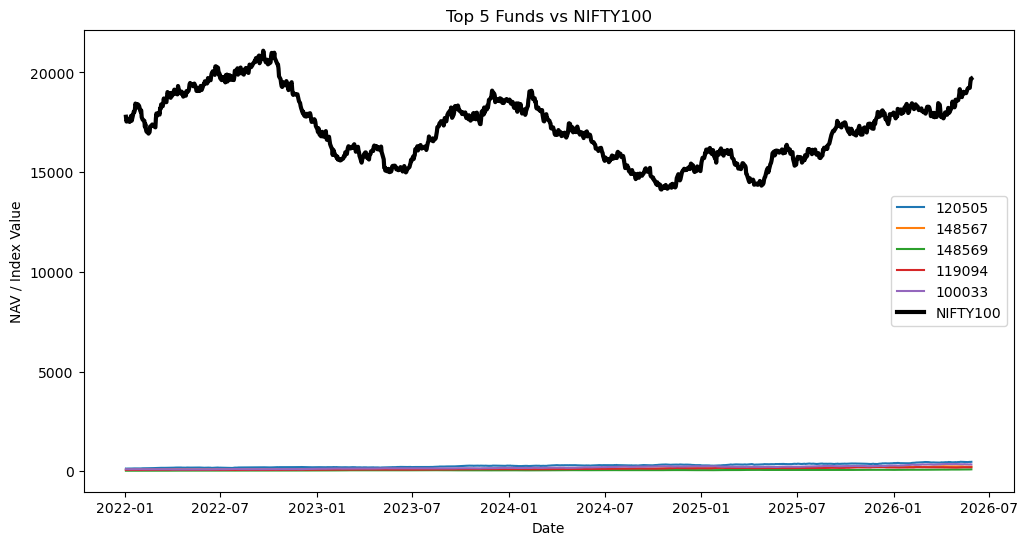

In [65]:
plt.figure(figsize=(12,6))

for fund in top5:
    temp = nav[nav["amfi_code"] == fund]
    plt.plot(temp["date"], temp["nav"], label=str(fund))

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    color="black",
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY100")
plt.xlabel("Date")
plt.ylabel("NAV / Index Value")
plt.legend()

plt.savefig("../charts/benchmark_comparison.png", dpi=300)

plt.show()

In [66]:
from pathlib import Path

output_dir = Path("../../reports/charts")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(output_dir / "benchmark_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

<Figure size 640x480 with 0 Axes>

In [67]:
from pathlib import Path

output_dir = Path("../../notebooks/reports/charts")
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()